In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [10]:
traffic = pd.read_csv(
    "../data/processed/traffic_density_timeseries.csv",
    parse_dates=["time_bin_5m"]
)

traffic.head()

,time_bin_5m,vehicle_count,avg_speed,pce_volume,crawling_count,hard_braking_count
0,2018-10-24 08:30:00,4724,17.826713,4383.0,3427,1419
1,2018-10-24 08:35:00,5106,17.355170,4733.0,3816,1654
2,2018-10-24 08:40:00,3905,16.790361,3633.5,2907,1174
3,2018-10-24 09:00:00,4620,14.779216,4308.0,3809,1441
4,2018-10-24 09:05:00,4983,14.968209,4627.0,4016,1578


In [11]:
traffic["date"] = traffic["time_bin_5m"].dt.date
traffic["clock_time"] = traffic["time_bin_5m"].dt.strftime("%H:%M")
traffic["hour"] = traffic["time_bin_5m"].dt.hour
traffic["minute"] = traffic["time_bin_5m"].dt.minute

traffic.head()

,time_bin_5m,vehicle_count,avg_speed,pce_volume,crawling_count,hard_braking_count,date,clock_time,hour,minute
0,2018-10-24 08:30:00,4724,17.826713,4383.0,3427,1419,2018-10-24,08:30,8,30
1,2018-10-24 08:35:00,5106,17.355170,4733.0,3816,1654,2018-10-24,08:35,8,35
2,2018-10-24 08:40:00,3905,16.790361,3633.5,2907,1174,2018-10-24,08:40,8,40
3,2018-10-24 09:00:00,4620,14.779216,4308.0,3809,1441,2018-10-24,09:00,9,0
4,2018-10-24 09:05:00,4983,14.968209,4627.0,4016,1578,2018-10-24,09:05,9,5


In [12]:
print("Shape:", traffic.shape)
print("Number of days:", traffic["date"].nunique())
print("Days:", traffic["date"].unique())

traffic.info()

Shape: (68, 10)
Number of days: 4
Days: [datetime.date(2018, 10, 24) datetime.date(2018, 10, 29)
 datetime.date(2018, 10, 30) datetime.date(2018, 11, 1)]
<class 'pandas.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   time_bin_5m         68 non-null     datetime64[us]
 1   vehicle_count       68 non-null     int64         
 2   avg_speed           68 non-null     float64       
 3   pce_volume          68 non-null     float64       
 4   crawling_count      68 non-null     int64         
 5   hard_braking_count  68 non-null     int64         
 6   date                68 non-null     object        
 7   clock_time          68 non-null     str           
 8   hour                68 non-null     int32         
 9   minute              68 non-null     int32         
dtypes: datetime64[us](1), float64(2), int32(2), int64(3), object(1), str(1)
memor

In [13]:
traffic.isna().sum()

time_bin_5m           0
vehicle_count         0
avg_speed             0
pce_volume            0
crawling_count        0
hard_braking_count    0
date                  0
clock_time            0
hour                  0
minute                0
dtype: int64

In [14]:
traffic.describe().T

,count,mean,min,25%,50%,75%,max,std
time_bin_5m,68,2018-10-29 08:10:39.705882,2018-10-24 08:30:00,2018-10-29 08:08:45,2018-10-30 08:07:30,2018-11-01 08:01:15,2018-11-01 10:15:00,NaN
vehicle_count,68.0,3716.838235,193.0,3253.0,4336.5,4660.75,5635.0,1451.677317
avg_speed,68.0,15.902643,10.028054,14.520737,15.770445,17.442022,19.884696,2.110133
pce_volume,68.0,3410.360294,177.0,2970.375,3920.0,4252.875,5239.5,1314.876221
crawling_count,68.0,2875.426471,109.0,2502.25,3316.5,3738.25,4298.0,1185.265954
hard_braking_count,68.0,1423.382353,0.0,765.75,1294.0,1663.25,3559.0,981.693055
hour,68.0,8.911765,8.0,8.0,9.0,9.25,10.0,0.767537
minute,68.0,19.485294,0.0,5.0,15.0,35.0,45.0,15.791073


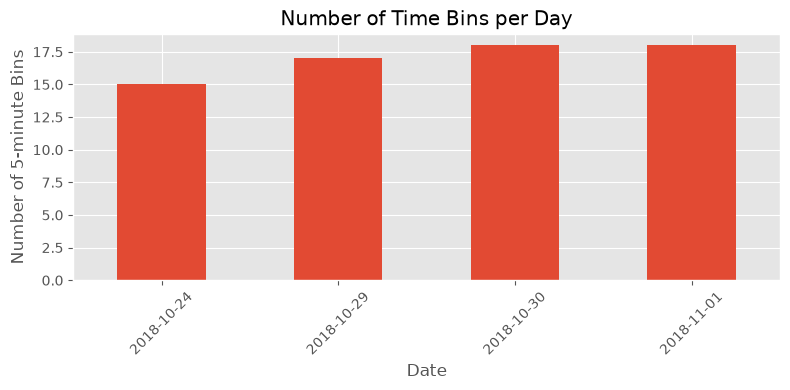

In [ ]:
traffic.groupby("date").size()

plt.figure(figsize=(8,4))

traffic.groupby("date").size().plot(kind="bar")

plt.title("Number of Time Bins per Day")
plt.xlabel("Date")
plt.ylabel("Number of 5-minute Bins")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
traffic["minute_of_day"] = (
    traffic["time_bin_5m"].dt.hour * 60
    + traffic["time_bin_5m"].dt.minute
)

traffic = traffic.sort_values(["date", "minute_of_day"])

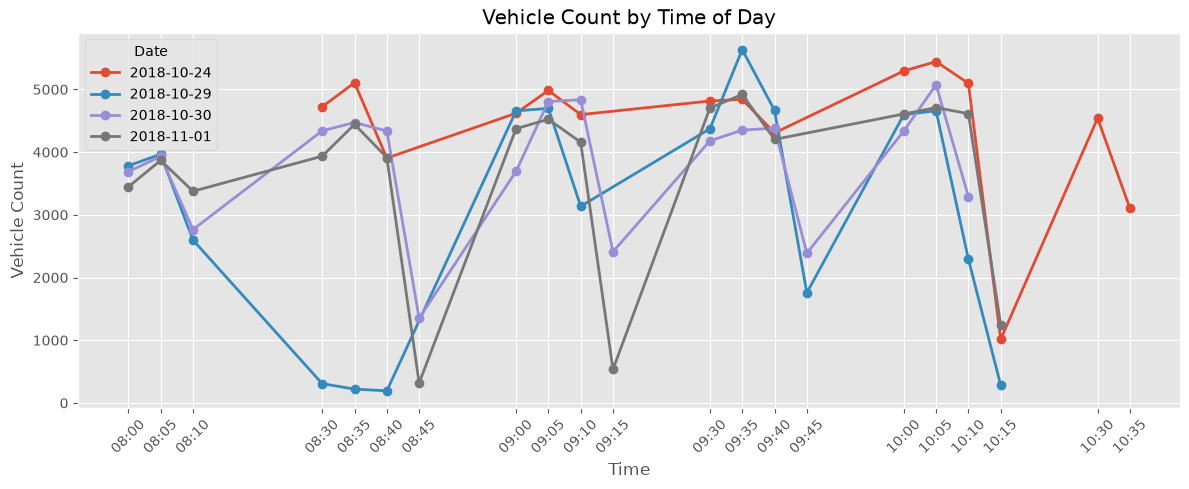

In [33]:
plt.figure(figsize=(12,5))

for date, df_day in traffic.groupby("date"):
    df_day = df_day.sort_values("minute_of_day")

    plt.plot(
        df_day["minute_of_day"],
        df_day["vehicle_count"],
        marker="o",
        linewidth=2,
        label=str(date)
    )

ticks = sorted(traffic["minute_of_day"].unique())
labels = [f"{t//60:02d}:{t%60:02d}" for t in ticks]

plt.xticks(ticks, labels, rotation=45)

plt.title("Vehicle Count by Time of Day")
plt.xlabel("Time")
plt.ylabel("Vehicle Count")
plt.legend(title="Date")

plt.tight_layout()
plt.show()

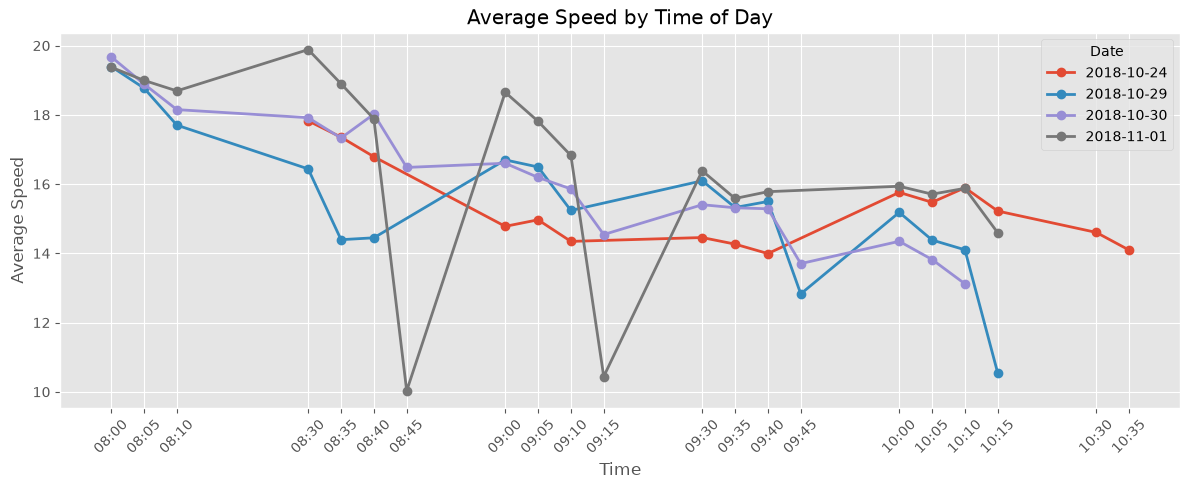

In [34]:
plt.figure(figsize=(12,5))

for date, df_day in traffic.groupby("date"):
    df_day = df_day.sort_values("minute_of_day")

    plt.plot(
        df_day["minute_of_day"],
        df_day["avg_speed"],
        marker="o",
        linewidth=2,
        label=str(date)
    )

ticks = sorted(traffic["minute_of_day"].unique())
labels = [f"{t//60:02d}:{t%60:02d}" for t in ticks]

plt.xticks(ticks, labels, rotation=45)

plt.title("Average Speed by Time of Day")
plt.xlabel("Time")
plt.ylabel("Average Speed")
plt.legend(title="Date")

plt.tight_layout()
plt.show()

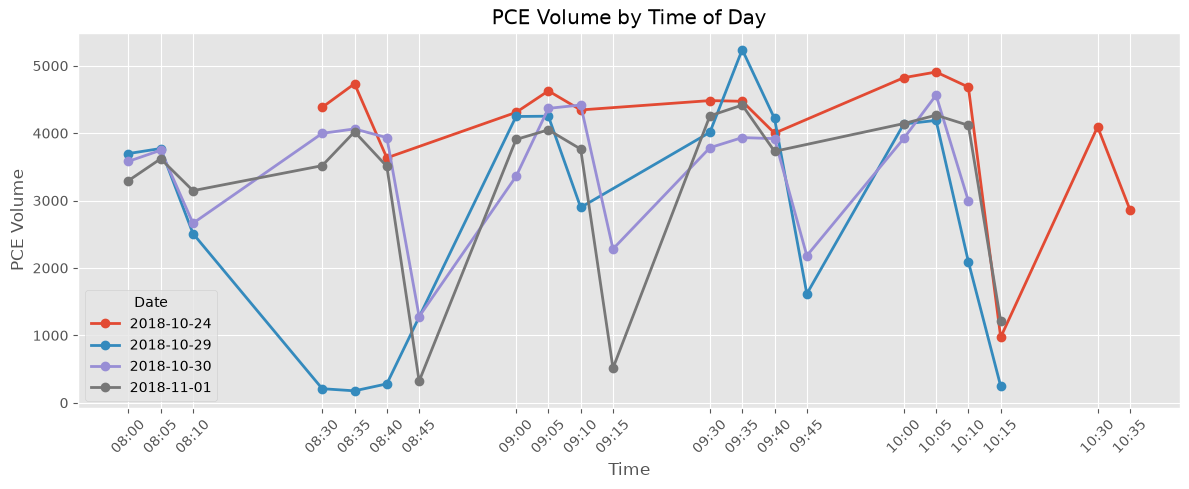

In [35]:
plt.figure(figsize=(12,5))

for date, df_day in traffic.groupby("date"):
    df_day = df_day.sort_values("minute_of_day")

    plt.plot(
        df_day["minute_of_day"],
        df_day["pce_volume"],
        marker="o",
        linewidth=2,
        label=str(date)
    )

ticks = sorted(traffic["minute_of_day"].unique())
labels = [f"{t//60:02d}:{t%60:02d}" for t in ticks]

plt.xticks(ticks, labels, rotation=45)

plt.title("PCE Volume by Time of Day")
plt.xlabel("Time")
plt.ylabel("PCE Volume")
plt.legend(title="Date")

plt.tight_layout()
plt.show()

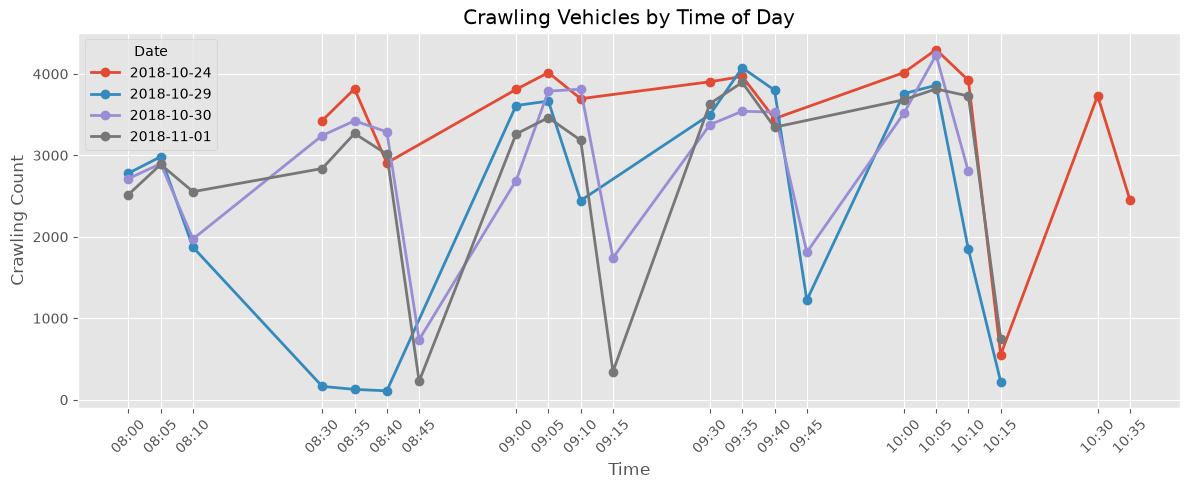

In [36]:
plt.figure(figsize=(12,5))

for date, df_day in traffic.groupby("date"):
    df_day = df_day.sort_values("minute_of_day")

    plt.plot(
        df_day["minute_of_day"],
        df_day["crawling_count"],
        marker="o",
        linewidth=2,
        label=str(date)
    )

ticks = sorted(traffic["minute_of_day"].unique())
labels = [f"{t//60:02d}:{t%60:02d}" for t in ticks]

plt.xticks(ticks, labels, rotation=45)

plt.title("Crawling Vehicles by Time of Day")
plt.xlabel("Time")
plt.ylabel("Crawling Count")
plt.legend(title="Date")

plt.tight_layout()
plt.show()

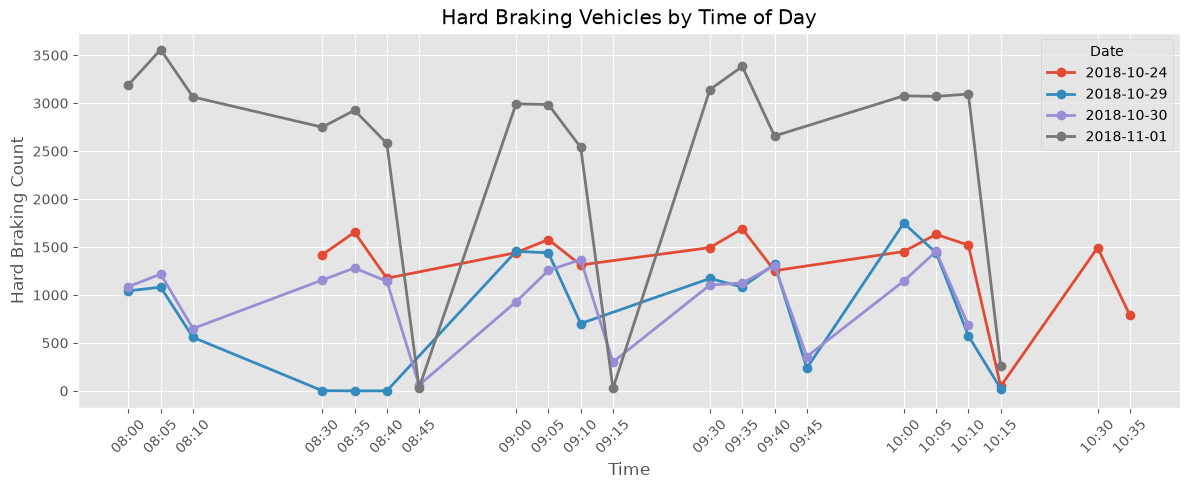

In [38]:
plt.figure(figsize=(12,5))

for date, df_day in traffic.groupby("date"):
    df_day = df_day.sort_values("minute_of_day")

    plt.plot(
        df_day["minute_of_day"],
        df_day["hard_braking_count"],
        marker="o",
        linewidth=2,
        label=str(date)
    )

ticks = sorted(traffic["minute_of_day"].unique())
labels = [f"{t//60:02d}:{t%60:02d}" for t in ticks]

plt.xticks(ticks, labels, rotation=45)

plt.title("Hard Braking Vehicles by Time of Day")
plt.xlabel("Time")
plt.ylabel("Hard Braking Count")
plt.legend(title="Date")

plt.tight_layout()
plt.show()

In [37]:
daily_summary = traffic.groupby("date").agg(
    avg_vehicle_count=("vehicle_count", "mean"),
    avg_speed=("avg_speed", "mean"),
    avg_pce_volume=("pce_volume", "mean"),
    avg_crawling_count=("crawling_count", "mean"),
    avg_hard_braking_count=("hard_braking_count", "mean")
).reset_index()

daily_summary

,date,avg_vehicle_count,avg_speed,avg_pce_volume,avg_crawling_count,avg_hard_braking_count
0,2018-10-24,4426.133333,15.321807,4088.533333,3464.333333,1330.000000
1,2018-10-29,3048.294118,15.502080,2811.294118,2355.235294,816.470588
2,2018-10-30,3813.111111,16.147954,3499.166667,2950.722222,978.944444
3,2018-11-01,3660.888889,16.519672,3322.194444,2800.666667,2518.833333


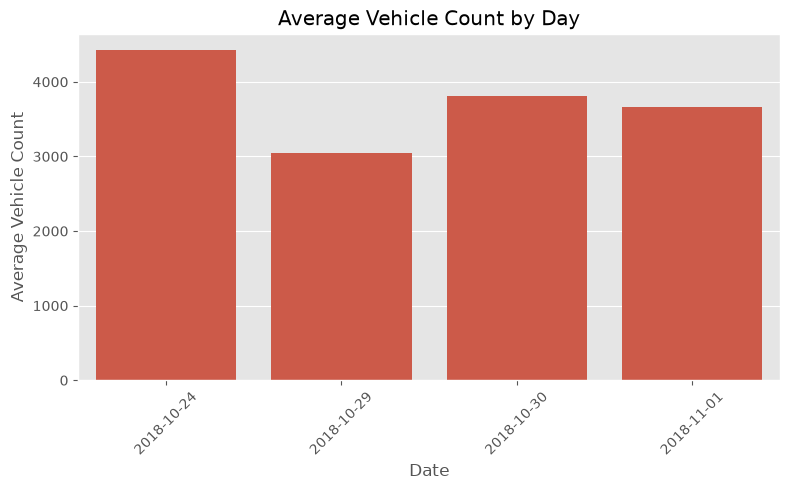

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=daily_summary,
    x="date",
    y="avg_vehicle_count"
)

plt.title("Average Vehicle Count by Day")
plt.xlabel("Date")
plt.ylabel("Average Vehicle Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
time_summary = traffic.groupby("clock_time").agg(
    avg_vehicle_count=("vehicle_count", "mean"),
    avg_speed=("avg_speed", "mean"),
    avg_pce_volume=("pce_volume", "mean"),
    avg_crawling_count=("crawling_count", "mean"),
    avg_hard_braking_count=("hard_braking_count", "mean")
).reset_index()

time_summary

,clock_time,avg_vehicle_count,avg_speed,avg_pce_volume,avg_crawling_count,avg_hard_braking_count
0,08:00,3638.666667,19.482996,3524.333333,2670.333333,1773.333333
1,08:05,3922.000000,18.885840,3712.500000,2923.000000,1952.666667
2,08:10,2913.000000,18.181634,2773.333333,2133.000000,1424.333333
3,08:30,3326.500000,18.016740,3026.625000,2418.000000,1331.500000
4,08:35,3560.500000,16.994625,3248.250000,2658.750000,1465.500000
5,08:40,3087.000000,16.785626,2838.625000,2329.500000,1224.000000
6,08:45,835.000000,13.254546,800.000000,481.500000,46.500000
7,09:00,4336.500000,16.682555,3954.750000,3343.000000,1704.500000
8,09:05,4752.750000,16.367226,4323.750000,3733.250000,1815.000000
9,09:10,4181.750000,15.567338,3855.750000,3284.250000,1480.750000


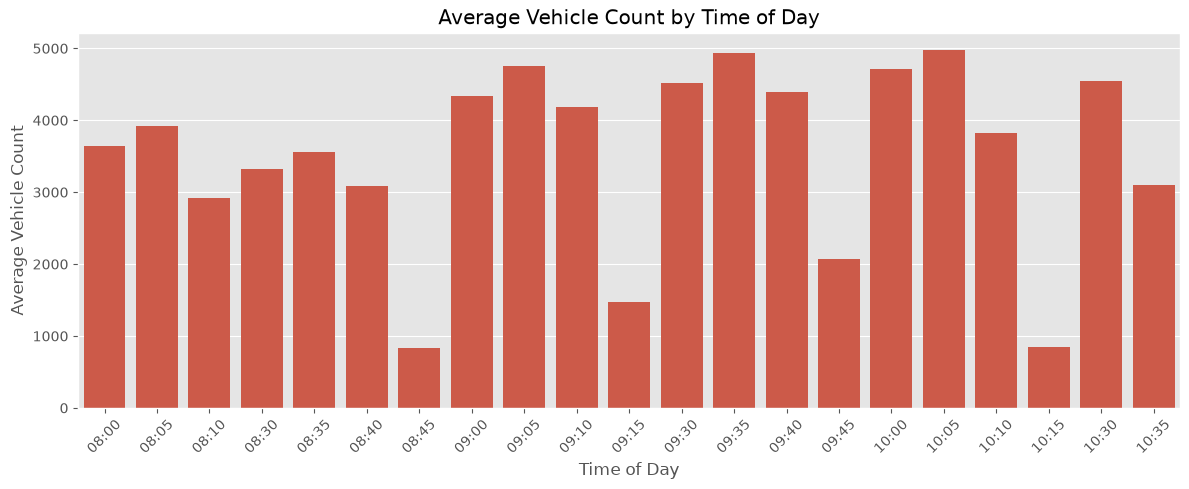

In [25]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=time_summary,
    x="clock_time",
    y="avg_vehicle_count"
)

plt.title("Average Vehicle Count by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Vehicle Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
pivot_vehicle = traffic.pivot_table(
    index="date",
    columns="clock_time",
    values="vehicle_count",
    aggfunc="mean"
)

pivot_vehicle

clock_time,08:00,08:05,08:10,08:30,08:35,08:40,08:45,09:00,09:05,09:10,09:15,09:30,09:35,09:40,09:45,10:00,10:05,10:10,10:15,10:30,10:35
date,,,,,,,,,,,,,,,,,,,,,
2018-10-24,NaN,NaN,NaN,4724.0,5106.0,3905.0,NaN,4620.0,4983.0,4598.0,NaN,4815.0,4842.0,4306.0,NaN,5294.0,5444.0,5097.0,1015.0,4541.0,3102.0
2018-10-29,3782.0,3966.0,2598.0,307.0,221.0,193.0,NaN,4658.0,4697.0,3136.0,NaN,4373.0,5635.0,4666.0,1756.0,4596.0,4659.0,2295.0,283.0,NaN,NaN
2018-10-30,3688.0,3932.0,2765.0,4340.0,4472.0,4337.0,1352.0,3694.0,4807.0,4835.0,2411.0,4180.0,4351.0,4382.0,2387.0,4336.0,5075.0,3292.0,NaN,NaN,NaN
2018-11-01,3446.0,3868.0,3376.0,3935.0,4443.0,3913.0,318.0,4374.0,4524.0,4158.0,536.0,4703.0,4919.0,4203.0,NaN,4608.0,4709.0,4614.0,1249.0,NaN,NaN


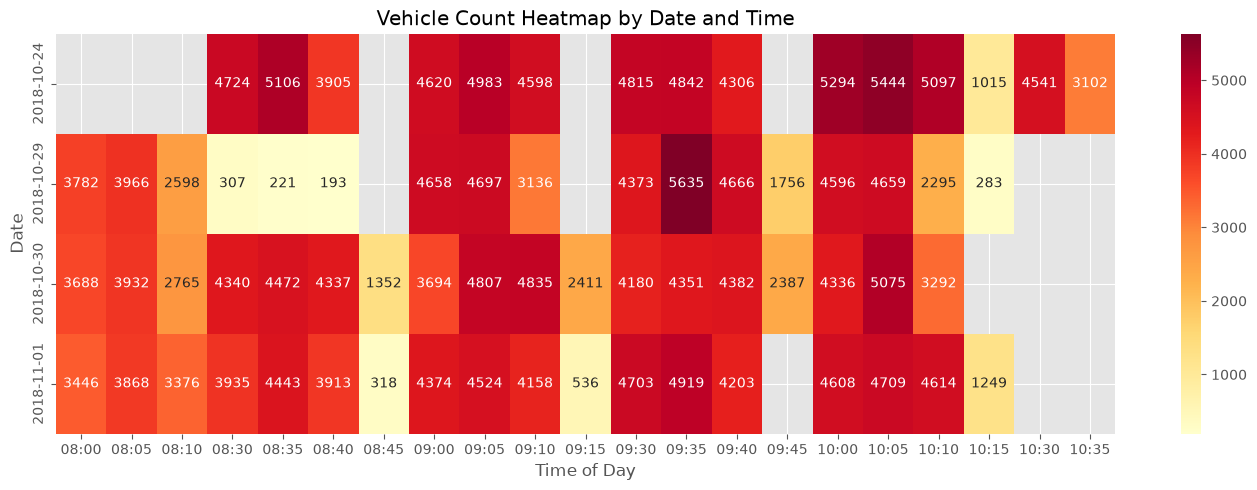

In [27]:
plt.figure(figsize=(14,5))

sns.heatmap(
    pivot_vehicle,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title("Vehicle Count Heatmap by Date and Time")
plt.xlabel("Time of Day")
plt.ylabel("Date")

plt.tight_layout()
plt.show()

In [28]:
corr = traffic[
    [
        "vehicle_count",
        "avg_speed",
        "pce_volume",
        "crawling_count",
        "hard_braking_count"
    ]
].corr()

corr

,vehicle_count,avg_speed,pce_volume,crawling_count,hard_braking_count
vehicle_count,1.000000,0.379466,0.998261,0.993220,0.629654
avg_speed,0.379466,1.000000,0.395621,0.304400,0.503458
pce_volume,0.998261,0.395621,1.000000,0.988945,0.616728
crawling_count,0.993220,0.304400,0.988945,1.000000,0.617010
hard_braking_count,0.629654,0.503458,0.616728,0.617010,1.000000


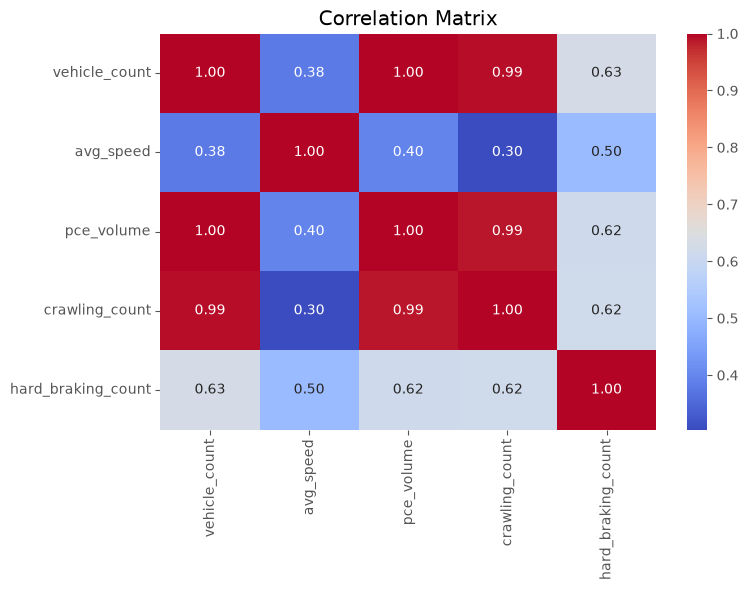

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [30]:
top_peak = traffic.sort_values(
    "vehicle_count",
    ascending=False
).head(10)

top_peak

,time_bin_5m,vehicle_count,avg_speed,pce_volume,crawling_count,hard_braking_count,date,clock_time,hour,minute
25,2018-10-29 09:35:00,5635,15.323749,5239.5,4075,1083,2018-10-29,09:35,9,35
10,2018-10-24 10:05:00,5444,15.473718,4907.0,4298,1632,2018-10-24,10:05,10,5
9,2018-10-24 10:00:00,5294,15.760450,4822.5,4015,1453,2018-10-24,10:00,10,0
1,2018-10-24 08:35:00,5106,17.355170,4733.0,3816,1654,2018-10-24,08:35,8,35
11,2018-10-24 10:10:00,5097,15.894448,4683.5,3921,1520,2018-10-24,10:10,10,10
48,2018-10-30 10:05:00,5075,13.821034,4563.5,4231,1454,2018-10-30,10:05,10,5
4,2018-10-24 09:05:00,4983,14.968209,4627.0,4016,1578,2018-10-24,09:05,9,5
62,2018-11-01 09:35:00,4919,15.584038,4416.5,3895,3383,2018-11-01,09:35,9,35
7,2018-10-24 09:35:00,4842,14.265609,4472.5,3968,1691,2018-10-24,09:35,9,35
41,2018-10-30 09:10:00,4835,15.860597,4417.5,3812,1368,2018-10-30,09:10,9,10


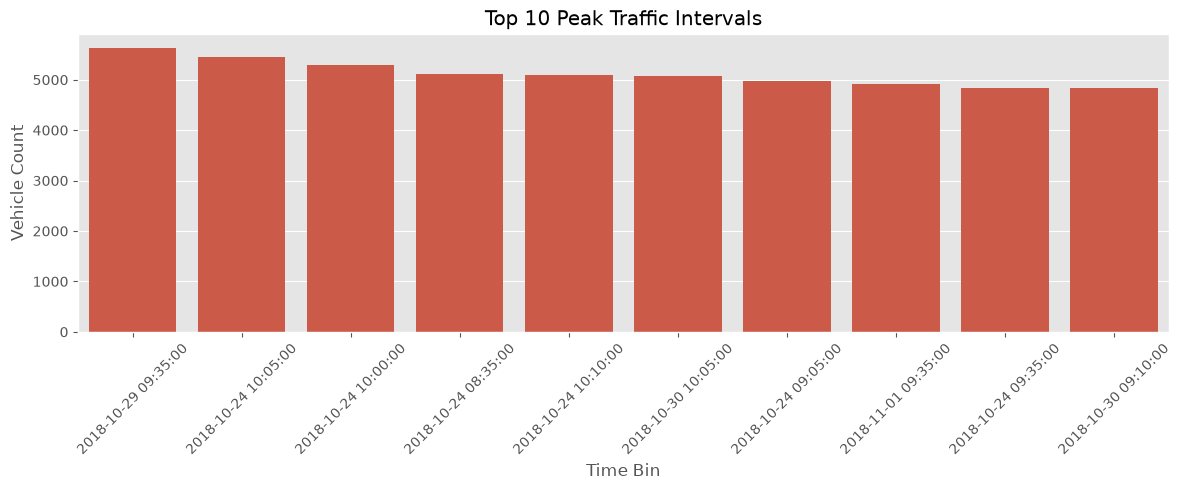

In [31]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=top_peak,
    x="time_bin_5m",
    y="vehicle_count"
)

plt.title("Top 10 Peak Traffic Intervals")
plt.xlabel("Time Bin")
plt.ylabel("Vehicle Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()